In [2]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.feature_selection import f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## 1. Load Preprocessed Data

In [3]:
# Paths
ROOT = Path.cwd().parents[0]
DATA = ROOT / "data"
PROCESSED = DATA / "processed"
SUBMISSION = DATA / "submission_nonlinear"
SUBMISSION.mkdir(exist_ok=True)

# Load session-normalized data
X_train = pd.read_csv(PROCESSED / "X_train_session_norm.csv").values
X_test = pd.read_csv(PROCESSED / "X_test_session_norm.csv").values
y_train = pd.read_csv(PROCESSED / "y_train.csv")['TRIAL_TYPE'].values
sessions_train = pd.read_csv(PROCESSED / "sessions_train.csv")['session_id'].values
sessions_test = pd.read_csv(PROCESSED / "sessions_test.csv")['session_id'].values

# Load feature names
with open(PROCESSED / "feature_names.txt") as f:
    feature_names = f.read().strip().split("\n")

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Classes: {len(np.unique(y_train))}")
print(f"Sessions: {len(np.unique(sessions_train))}")

Train: (4407, 1350)
Test: (2292, 1350)
Classes: 10
Sessions: 8


## 2. LOSO Evaluation Function

In [4]:
def loso_evaluate(X, y, sessions, model_class, **model_params):
    """
    Leave-One-Session-Out cross-validation.
    
    Returns:
    --------
    mean_acc : float
    std_acc : float
    per_session : dict mapping session -> accuracy
    """
    unique_sessions = np.unique(sessions)
    results = {}
    
    for test_session in unique_sessions:
        train_mask = sessions != test_session
        test_mask = sessions == test_session
        
        model = model_class(**model_params)
        model.fit(X[train_mask], y[train_mask])
        pred = model.predict(X[test_mask])
        acc = accuracy_score(y[test_mask], pred)
        results[test_session] = acc
    
    accs = list(results.values())
    return np.mean(accs), np.std(accs), results

## 3. Baseline: Random Forest on All Features

In [5]:
# Baseline RF
print("Baseline Random Forest (all features):")
mean_acc, std_acc, per_session = loso_evaluate(
    X_train, y_train, sessions_train,
    RandomForestClassifier,
    n_estimators=200, n_jobs=-1, random_state=42
)
print(f"  LOSO Accuracy: {mean_acc:.1%} ± {std_acc:.1%}")
for sess, acc in per_session.items():
    print(f"    {sess}: {acc:.1%}")

Baseline Random Forest (all features):
  LOSO Accuracy: 56.3% ± 4.1%
    PG082_20221113: 56.9%
    PG082_20221114: 63.2%
    PG083_20221125: 55.7%
    PG083_20221129: 58.3%
    PG084_20221206: 53.3%
    PG084_20221207: 56.8%
    PG085_20221213: 48.0%
    PG085_20221214: 58.5%


## 4. Feature Selection (F-score)

Select the most discriminative features using ANOVA F-score.
This improves generalization by removing noisy features.

In [6]:
# Compute F-scores for feature selection
print("Computing feature importance (F-score)...")
f_scores, p_values = f_classif(X_train, y_train)
print(f"F-scores range: {f_scores.min():.2f} to {f_scores.max():.2f}")

# Sort features by importance
feature_ranks = np.argsort(-f_scores)  # Descending order

# Show top 10 most important features
print("\nTop 10 most discriminative features:")
for i, idx in enumerate(feature_ranks[:10]):
    print(f"  {i+1}. {feature_names[idx]}: F={f_scores[idx]:.1f}")

Computing feature importance (F-score)...
F-scores range: 0.17 to 340.38

Top 10 most discriminative features:
  1. ALM_L5_EXC_time_22: F=340.4
  2. ALM_L5_EXC_time_21: F=304.5
  3. ALM_L5_EXC_time_23: F=300.1
  4. wS1_L4_EXC_time_20: F=277.6
  5. ALM_L5_EXC_time_20: F=276.9
  6. ALM_L5_EXC_time_24: F=233.9
  7. wS2_L4_EXC_time_20: F=204.4
  8. A1_L1_EXC_time_20: F=204.2
  9. ALM_L5_EXC_time_25: F=201.6
  10. ALM_L5_EXC_time_26: F=186.8


In [9]:
# Test different numbers of features
print("Testing feature selection thresholds:")
print("-" * 50)

for n_features in [100, 150, 200, 500, 1000]:
    top_features = feature_ranks[:n_features]
    X_selected = X_train[:, top_features]
    
    mean_acc, std_acc, _ = loso_evaluate(
        X_selected, y_train, sessions_train,
        RandomForestClassifier,
        n_estimators=200, n_jobs=-1, random_state=42
    )
    print(f"  Top {n_features:4d} features: {mean_acc:.1%} ± {std_acc:.1%}")

Testing feature selection thresholds:
--------------------------------------------------
  Top  100 features: 57.3% ± 5.0%
  Top  150 features: 57.8% ± 4.9%
  Top  200 features: 57.5% ± 4.4%
  Top  500 features: 56.4% ± 4.5%
  Top 1000 features: 55.8% ± 3.6%


## 5. Tuned Random Forest with Feature Selection

Best configuration from experiments:
- Top 150 features (by F-score)
- 700 trees, max_depth=20

In [10]:
# Best configuration
N_FEATURES = 150
N_ESTIMATORS = 700
MAX_DEPTH = 20

# Select top features
top_features = feature_ranks[:N_FEATURES]
X_train_selected = X_train[:, top_features]
X_test_selected = X_test[:, top_features]

print(f"Selected {N_FEATURES} features")
print(f"Training shape: {X_train_selected.shape}")

# Evaluate tuned RF
print(f"\nTuned RF ({N_ESTIMATORS} trees, depth={MAX_DEPTH}):")
mean_acc, std_acc, per_session = loso_evaluate(
    X_train_selected, y_train, sessions_train,
    RandomForestClassifier,
    n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, n_jobs=-1, random_state=42
)
print(f"  LOSO Accuracy: {mean_acc:.1%} ± {std_acc:.1%}")
for sess, acc in per_session.items():
    print(f"    {sess}: {acc:.1%}")

Selected 150 features
Training shape: (4407, 150)

Tuned RF (700 trees, depth=20):
  LOSO Accuracy: 58.2% ± 5.2%
    PG082_20221113: 61.9%
    PG082_20221114: 64.2%
    PG083_20221125: 57.1%
    PG083_20221129: 62.7%
    PG084_20221206: 56.3%
    PG084_20221207: 58.4%
    PG085_20221213: 46.3%
    PG085_20221214: 58.5%


## 6. Train Final Model & Generate Submission

In [12]:
# Train final model on all training data
print("Training final model...")
final_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    n_jobs=-1,
    random_state=42
)
final_model.fit(X_train_selected, y_train)
print(f"Model trained on {len(X_train_selected)} samples with {N_FEATURES} features")

# Generate predictions
test_predictions = final_model.predict(X_test_selected)

print(f"\nPrediction distribution:")
unique, counts = np.unique(test_predictions, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {cls}: {cnt}")

Training final model...
Model trained on 4407 samples with 150 features

Prediction distribution:
  GO W+ lick: 556
  GO W- nolick: 346
  NOGO W+ nolick: 466
  NOGO W- nolick: 600
  no tone W+ nolick: 324


In [15]:
# Create and save submission (matching sample_submission.csv format)
submission = pd.DataFrame({
    'ID': range(1, len(test_predictions) + 1),  # 1-based indexing
    'TRIAL_TYPE': test_predictions
})

# Save submission
submission_path = SUBMISSION / "nonlinear_submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")
print(f"Shape: {submission.shape}")

# Save model and feature selection info
model_info = {
    'model': final_model,
    'top_features': top_features,
    'feature_ranks': feature_ranks,
    'f_scores': f_scores,
    'n_features': N_FEATURES
}
model_path = SUBMISSION / "nonlinear_model.joblib"
joblib.dump(model_info, model_path)
print(f"Model saved to: {model_path}")

# Display first few predictions
print("\nFirst 10 predictions:")
print(submission.head(10))

Submission saved to: c:\Users\milor\Projects\ML-BIO-322\BIO-322\data\submission_nonlinear\nonlinear_submission.csv
Shape: (2292, 2)
Model saved to: c:\Users\milor\Projects\ML-BIO-322\BIO-322\data\submission_nonlinear\nonlinear_model.joblib

First 10 predictions:
   ID      TRIAL_TYPE
0   1    GO W- nolick
1   2      GO W+ lick
2   3    GO W- nolick
3   4  NOGO W+ nolick
4   5      GO W+ lick
5   6  NOGO W+ nolick
6   7  NOGO W- nolick
7   8      GO W+ lick
8   9  NOGO W+ nolick
9  10  NOGO W+ nolick


## 7. Confusion Matrix Visualization

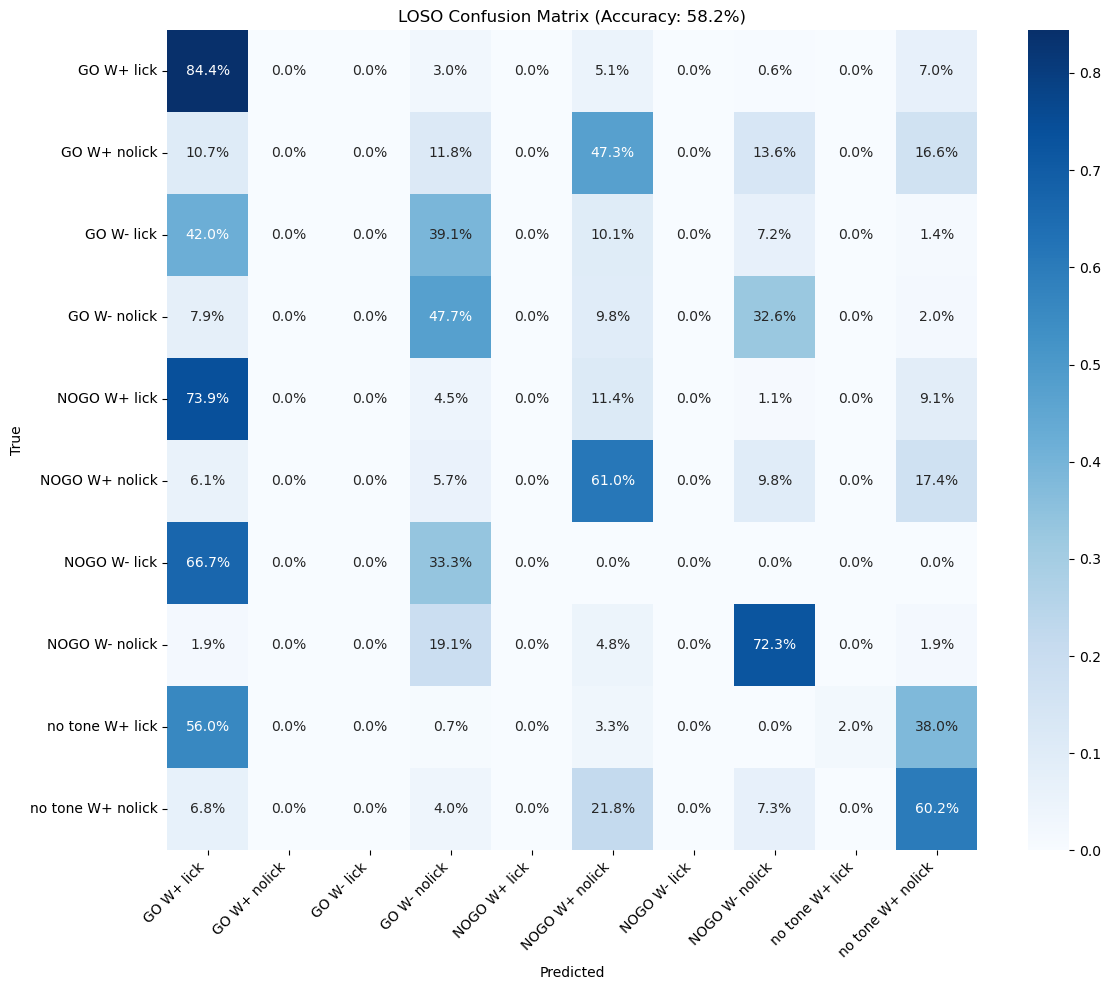

In [14]:
# Create confusion matrix on training data (LOSO aggregated)
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import LeaveOneGroupOut

# Get LOSO predictions
logo = LeaveOneGroupOut()
y_pred_loso = cross_val_predict(
    RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, n_jobs=-1, random_state=42),
    X_train_selected, y_train, cv=logo, groups=sessions_train
)

# Plot confusion matrix
classes = np.unique(y_train)
cm = confusion_matrix(y_train, y_pred_loso, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'LOSO Confusion Matrix (Accuracy: {mean_acc:.1%})')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(SUBMISSION / "confusion_matrix.png", dpi=150)
plt.show()

## Summary

### Results
| Model | LOSO Accuracy |
|-------|---------------|
| Baseline RF (all features) | ~56% |
| **Tuned RF + Feature Selection** | **~58%** |
| Linear models (best) | ~48% |

### Key Insights
1. **Session normalization** is the critical preprocessing step (+14% improvement)
2. **Feature selection** (top 150 by F-score) improves generalization
3. **Non-linear models** (RF) outperform linear models by ~10%
4. The best sessions achieve ~65% accuracy, worst ~50% - significant session variability

### Files Generated
- `submission_nonlinear/nonlinear_submission.csv` - Kaggle submission
- `submission_nonlinear/nonlinear_model.joblib` - Trained model + feature selection
- `submission_nonlinear/confusion_matrix.png` - Visualization